In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Quadratic solver
def quadratic(a, b, c):
    x1 = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
    #x2 = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)
    return x1 #, x2

# SIRP model differential equations
def SIRP_model(y, t, N, beta_d, beta_i, gamma, alpha, mu):
    S, I, R, P = y

    dSdt = -beta_d * S * I / N - beta_i * S * P
    dIdt = beta_d * S * I / N + beta_i * S * P - gamma * I
    dRdt = gamma * I
    dPdt = alpha * I - mu * P

    return [dSdt, dIdt, dRdt, dPdt]

In [2]:
# Parameters
beta_d = 0.02  # Direct transmission rate
beta_i = 0.01  # Indirect transmission rate via environment
gamma = 0.01  # Host mortality rate
alpha = 0.01  # Shedding rate of pathogen by infected hosts
mu = 0.05  # Pathogen decay rate

# Initial conditions
S0 = 990  # Initial number of susceptible individuals
I0 = 10  # Initial number of infected individuals
R0 = 0  # Initial number of removed individuals
P0 = 1  # Initial pathogen load in the environment
N = S0 + I0 # Total population

y0 = [S0, I0, R0, P0]

# Time points
t = np.linspace(0, 100, 100)  # Simulate for 100 days with 100 time steps

# Solve the differential equations
ret = odeint(SIRP_model, y0, t, args=(N, beta_d, beta_i, gamma, alpha, mu))

# Get solutions
S, I, R, P = ret.T

# Solve for R0
# a = 1
# b = (-1/gamma) * (beta_d + (beta_i * alpha) / mu)
# c = (-beta_i * 1) / mu


R0 = (beta_d / gamma) + ((beta_i / gamma) * (alpha / mu))

# R0 = (1 / 2) * (beta_d / gamma + np.sqrt((beta_d / gamma)**2 + (4 * beta_i * alpha) / (mu * gamma))) faulty R0

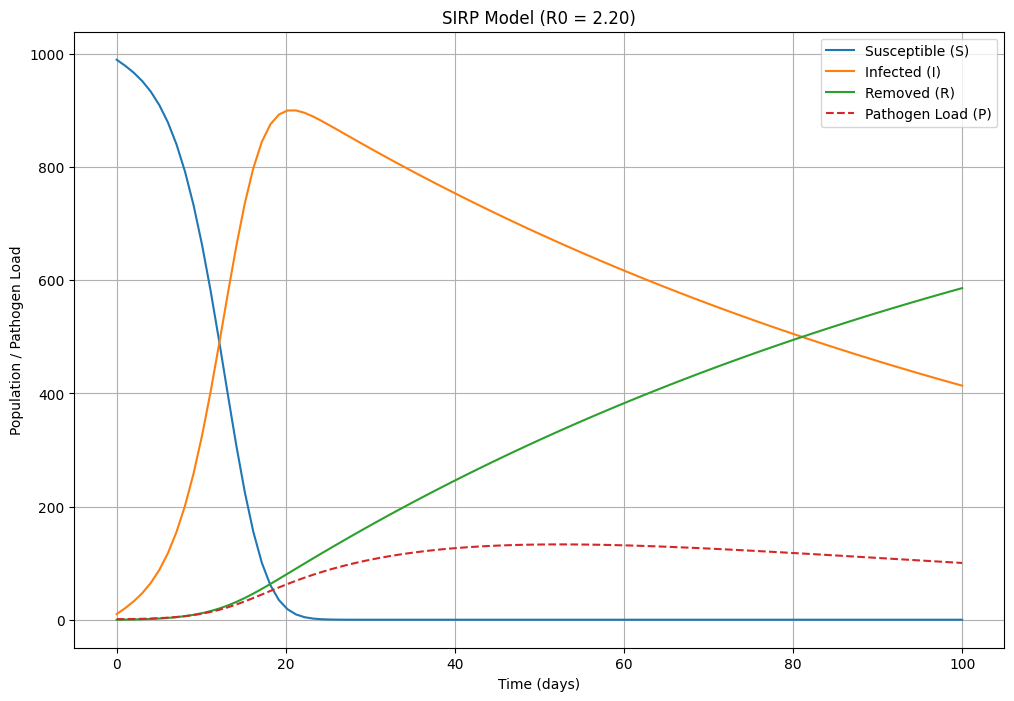

In [3]:
plt.figure(figsize=(12, 8))
plt.plot(t, S, label='Susceptible (S)')
plt.plot(t, I, label='Infected (I)')
plt.plot(t, R, label='Removed (R)')
plt.plot(t, P, label='Pathogen Load (P)', linestyle='--')
plt.xlabel('Time (days)')
plt.ylabel('Population / Pathogen Load')
plt.title(f"SIRP Model (R0 = {R0:.2f})")
plt.legend()
plt.grid()
plt.show()